<a href="https://colab.research.google.com/github/lawrence-kagugo/kenya-telecom-churn-analysis/blob/main/notebooks/04_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kenya Telecom Customer Churn — Exploratory Data Analysis
**Step:** 8 - EDA

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CLEANED dataset this time, not raw - all our Step 7 fixes are in here.
url = "https://raw.githubusercontent.com/lawrence-kagugo/kenya-telecom-churn-analysis/refs/heads/main/data/processed/kenya_telecom_churn_cleaned.csv"
df = pd.read_csv(url, parse_dates=['DateOfBirth', 'JoinDate', 'ChurnDate'])

print("Loaded:", df.shape)
print(df['DateOfBirth'].dtype)  # confirm dates loaded correctly this time

Loaded: (5000, 70)
datetime64[ns]


ContractType
Month-to-Month    26.710574
12 Months         15.584416
24 Months         14.179104
Name: Churn, dtype: float64


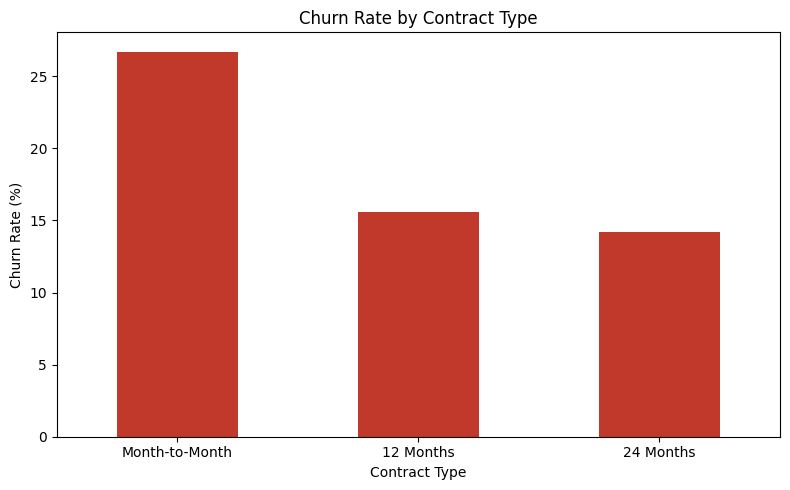

In [4]:
# Calculate churn RATE (not just count) by ContractType.
# We group by ContractType, then within each group calculate what % churned.
churn_by_contract = df.groupby('ContractType')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print(churn_by_contract)

# Now visualize it
plt.figure(figsize=(8, 5))
churn_by_contract.plot(kind='bar', color='#c0392b')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Business Question 1: Churn rate by Contract Type

**Finding:** Month-to-Month contracts churn at 26.7%, compared to 15.6% for
12-Month and 14.2% for 24-Month contracts - nearly double the longer-term rate.

**Interpretation:** Contract length appears to be one of the strongest churn
predictors identified so far. This suggests contract structure itself (not just
customer quality) may drive retention - customers on month-to-month plans have
no switching cost, making churn low-friction.

**Business implication:** Migrating month-to-month customers to fixed-term
contracts (e.g. via incentivized upgrade offers) could be a high-leverage
retention lever - worth flagging for the Recommendations section.

TenureGroup
0-6 months      49.380165
7-12 months     39.949109
13-24 months    28.851541
25-48 months    21.533442
49+ months       9.307764
Name: Churn, dtype: float64


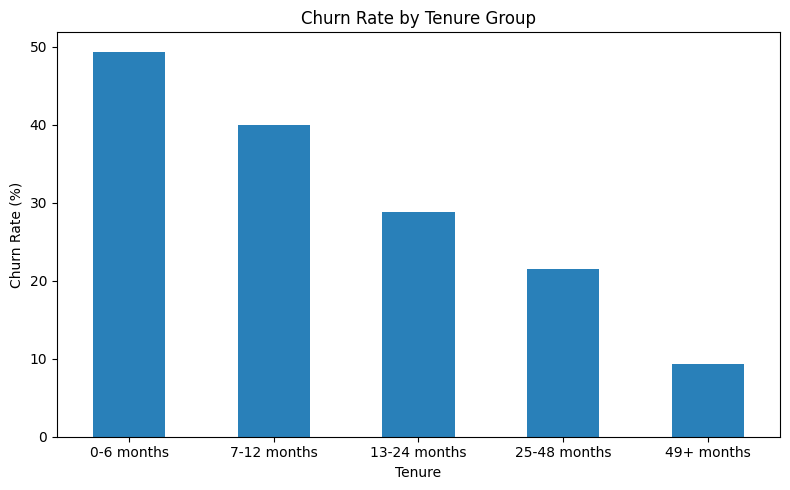

In [5]:
# Bucket TenureMonths into ranges for readability.
bins = [0, 6, 12, 24, 48, 100]
labels = ['0-6 months', '7-12 months', '13-24 months', '25-48 months', '49+ months']
df['TenureGroup'] = pd.cut(df['TenureMonths'], bins=bins, labels=labels)

churn_by_tenure = df.groupby('TenureGroup', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(churn_by_tenure)

plt.figure(figsize=(8, 5))
churn_by_tenure.plot(kind='bar', color='#2980b9')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Business Question 2: Churn rate by Tenure

**Finding:** Churn rate declines steadily and consistently with tenure:
0-6 months (49.4%), 7-12 months (40.0%), 13-24 months (28.9%),
25-48 months (21.5%), 49+ months (9.3%).

**Interpretation:** The first 6-12 months represent the highest-risk period in
the customer lifecycle by a wide margin. This is a stronger and more consistent
pattern than the ContractType finding, suggesting onboarding/early engagement
quality may matter more than contract structure alone.

**Business implication:** Retention investment may have the highest ROI when
concentrated in the first 6-12 months post-signup (e.g. proactive onboarding
check-ins, early engagement campaigns) rather than spread evenly across the
customer base.

       SupportTickets  Complaints  Escalations
Churn                                         
No           1.968941    0.485743     0.016802
Yes          2.944030    0.927239     0.073694


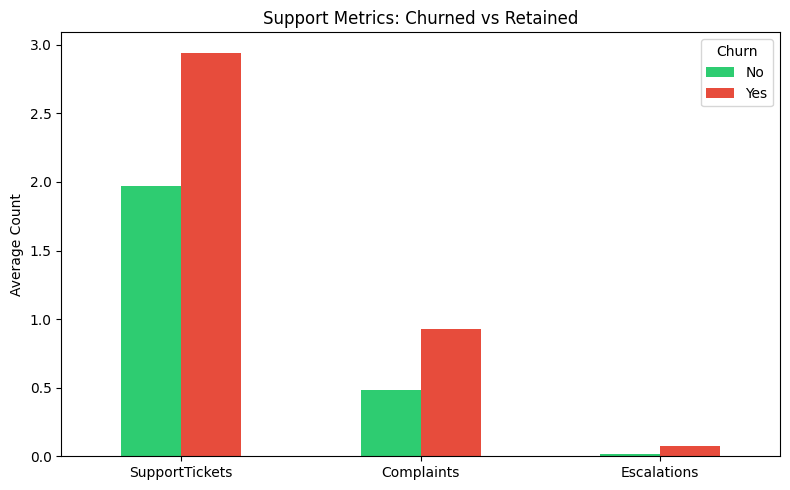

In [6]:
# Compare average support-related metrics between churned and retained customers.
support_cols = ['SupportTickets', 'Complaints', 'Escalations']
support_by_churn = df.groupby('Churn')[support_cols].mean()
print(support_by_churn)

# Visualize as grouped bar chart
support_by_churn.T.plot(kind='bar', figsize=(8, 5), color=['#2ecc71', '#e74c3c'])
plt.title('Support Metrics: Churned vs Retained')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## Business Question 3: Support metrics and churn

**Finding:** Churned customers average higher SupportTickets (2.94 vs 1.97),
Complaints (0.93 vs 0.49), and Escalations (0.07 vs 0.02) than retained customers.

**Interpretation:** All three support-related metrics move in the direction
expected if poor support experience drives churn. However, Escalations is a
rare event for both groups (means near zero) - the relative jump looks large
but the absolute difference is small, so this needs formal statistical testing
(Step 9) before treating it as a confirmed driver rather than noise.

       LatePayments  OutstandingBalance
Churn                                  
No         0.900458          427.703152
Yes        0.839552          472.308563


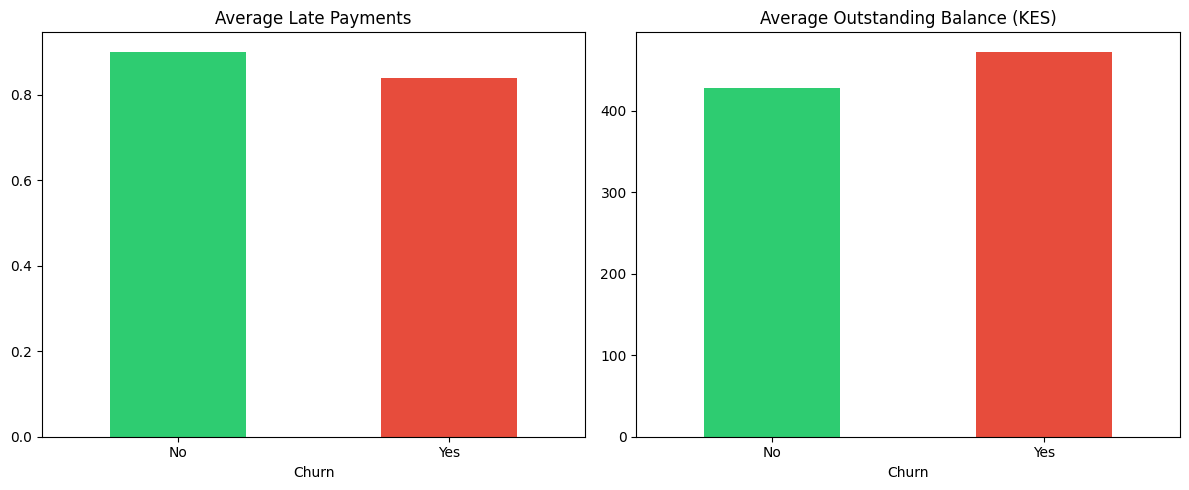

In [7]:
# Compare billing behavior between churned and retained customers.
billing_cols = ['LatePayments', 'OutstandingBalance']
billing_by_churn = df.groupby('Churn')[billing_cols].mean()
print(billing_by_churn)

# Two separate charts since the scales differ hugely (count vs currency)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

billing_by_churn['LatePayments'].plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Average Late Payments')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

billing_by_churn['OutstandingBalance'].plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Average Outstanding Balance (KES)')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

## Business Question 4: Billing behavior and churn

**Finding:** LatePayments is slightly LOWER for churned customers (0.84 vs 0.90) -
contradicting the hypothesis. OutstandingBalance is moderately higher for churned
customers (472.31 vs 427.70 KES).

**Interpretation:** Mixed/weak evidence for a billing-friction driver. Higher
outstanding balance offers some support, but lower late payments among churned
customers contradicts the expected direction. This suggests billing behavior is
NOT a strong standalone churn driver in this dataset - unlike Contract Type
(Q1) and Tenure (Q2), which showed clear, consistent patterns.

**Business implication:** Retention interventions should likely prioritize
contract structure and early-tenure engagement over billing/collections-focused
outreach, based on evidence so far.

       LoginsPerMonth  SessionsPerWeek  FeatureAdoptionRate
Churn                                                      
No          20.625764         5.155550            53.924465
Yes         18.204291         4.599813            47.920429


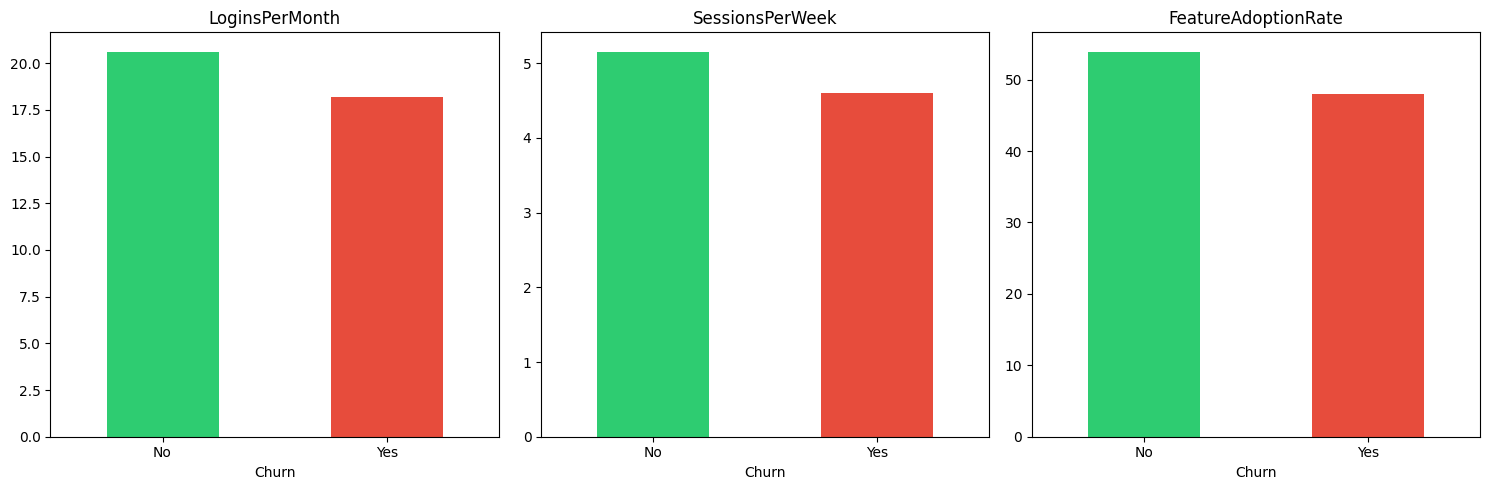

In [8]:
# Compare engagement metrics between churned and retained customers.
engagement_cols = ['LoginsPerMonth', 'SessionsPerWeek', 'FeatureAdoptionRate']
engagement_by_churn = df.groupby('Churn')[engagement_cols].mean()
print(engagement_by_churn)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(engagement_cols):
    engagement_by_churn[col].plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

## Business Question 5: Engagement metrics and churn

**Finding:** Churned customers show lower engagement across all three metrics:
LoginsPerMonth (18.2 vs 20.6), SessionsPerWeek (4.60 vs 5.16), and
FeatureAdoptionRate (47.9% vs 53.9%).

**Interpretation:** All three engagement metrics consistently point in the same
direction, supporting the "disengagement precedes churn" hypothesis. This is a
more coherent pattern than Question 4 (billing), where signals were mixed.

**Business implication:** Proactively monitoring engagement drop-off (e.g. a
sudden decline in logins/feature usage) could serve as an early-warning signal
for at-risk customers, complementing the tenure-based risk window identified
in Question 2.

       NetPromoterScore  CustomerSatisfactionScore  SurveyScore  ProductRating
Churn                                                                         
No             6.854888                   4.186609    82.714303       4.136992
Yes            6.392724                   3.869403    76.761843       3.853456


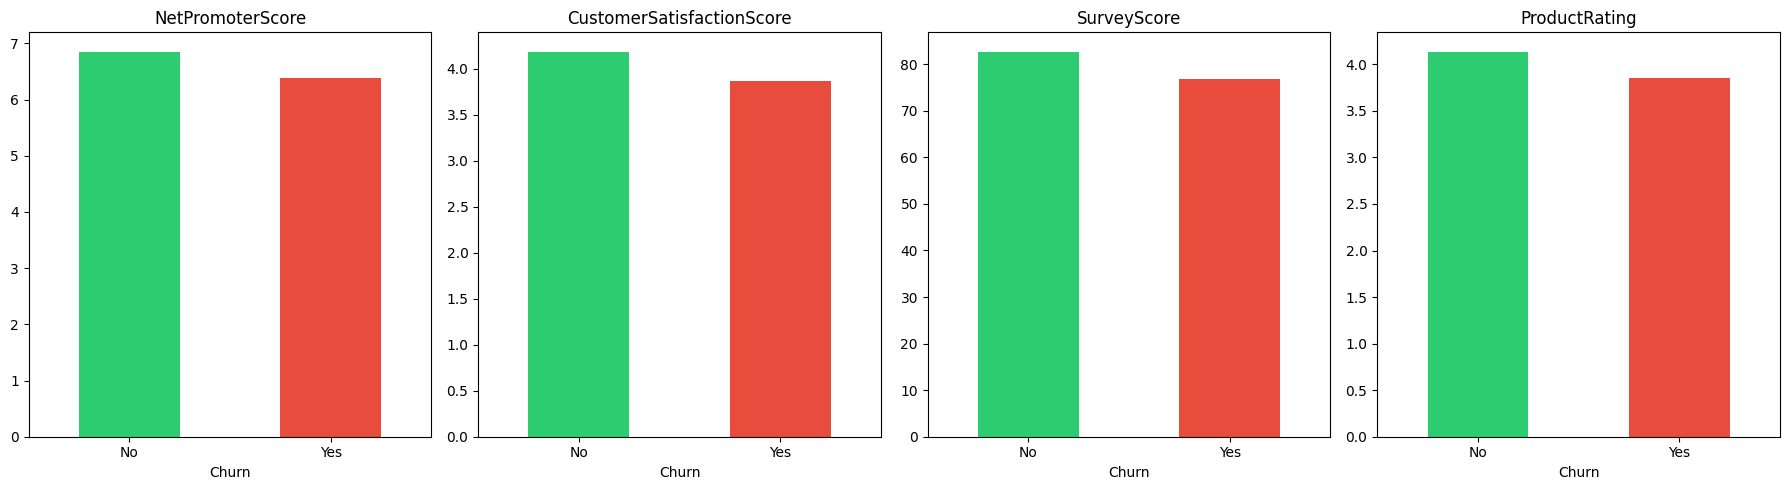

In [9]:
# Compare satisfaction-related scores between churned and retained customers.
satisfaction_cols = ['NetPromoterScore', 'CustomerSatisfactionScore', 'SurveyScore', 'ProductRating']
satisfaction_by_churn = df.groupby('Churn')[satisfaction_cols].mean()
print(satisfaction_by_churn)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(satisfaction_cols):
    satisfaction_by_churn[col].plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

## Business Question 6: Satisfaction scores and churn

**Finding:** All four satisfaction metrics are lower for churned customers:
NetPromoterScore (6.39 vs 6.85), CustomerSatisfactionScore (3.87 vs 4.19),
SurveyScore (76.8 vs 82.7), and ProductRating (3.85 vs 4.14).

**Interpretation:** Stated satisfaction aligns with the behavioral engagement
pattern from Question 5 - churned customers both use the product less AND
report feeling less satisfied with it. This convergence between stated and
behavioral data strengthens confidence that disengagement/dissatisfaction is
a genuine churn driver, not a coincidence in one data source.

**Business implication:** Combining engagement drop-off (behavioral) with
declining satisfaction survey scores (stated) could form a more robust early-
warning signal than either alone.

Churn
No     4.676517e+08
Yes    1.329767e+08
Name: CustomerLifetimeValue, dtype: float64

Percent of total CLV lost to churn: 22.14%


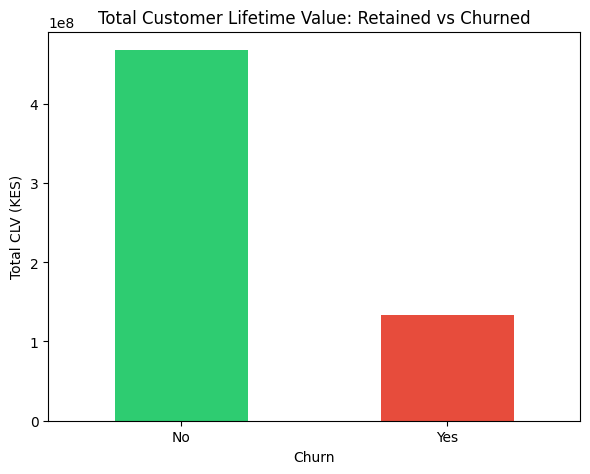

In [10]:
# Total CLV by churn status - the financial scale of churn.
clv_by_churn = df.groupby('Churn')['CustomerLifetimeValue'].sum()
print(clv_by_churn)

pct_at_risk = clv_by_churn['Yes'] / (clv_by_churn['Yes'] + clv_by_churn['No']) * 100
print(f"\nPercent of total CLV lost to churn: {pct_at_risk:.2f}%")

plt.figure(figsize=(6, 5))
clv_by_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Total Customer Lifetime Value: Retained vs Churned')
plt.ylabel('Total CLV (KES)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Business Question 7: Total revenue/CLV at risk

**Finding:** Churned customers represent KES 132.98M in cumulative
CustomerLifetimeValue, against KES 467.65M for retained customers -
22.14% of total CLV lost to churn (consistent with earlier Data
Understanding check).

**Interpretation:** This closely tracks the 21.44% overall churn rate,
confirming churned customers are not disproportionately high- or low-value
on average, in aggregate. The next question breaks this down by segment
to see if that holds true at a more granular level.

Churn rate by segment (%):
CustomerSegment
Government     37.301587
Corporate      35.283364
SME            24.872579
Residential    16.850220
Student        16.532258
Name: Churn, dtype: float64

Total CLV lost by segment (KES):
CustomerSegment
Corporate      48914658.61
SME            31996260.51
Residential    25929827.21
Government     23800246.76
Student         2335690.28
Name: CustomerLifetimeValue, dtype: float64


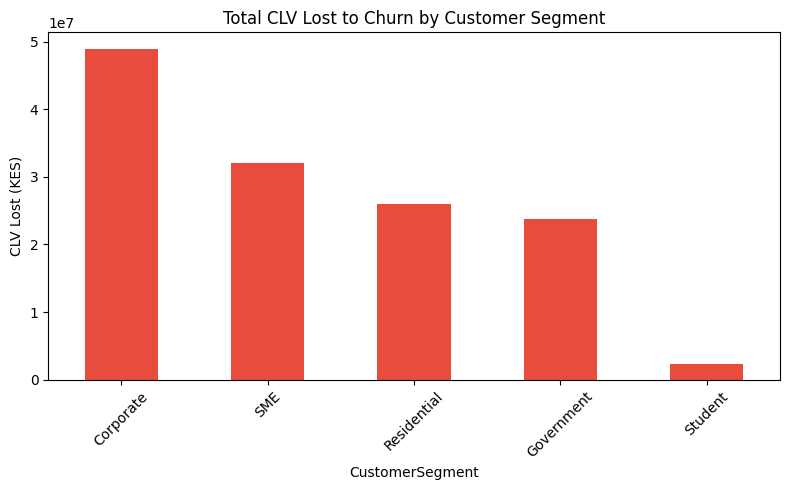

In [11]:
# For each segment: churn RATE (%) and total CLV LOST (KES, churned only)
# Calculating both side-by-side lets us see if the highest-risk segment
# is the same as the highest-financial-impact segment, or if they diverge.
churned_only = df[df['Churn'] == 'Yes']

segment_churn_rate = df.groupby('CustomerSegment')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
segment_clv_lost = churned_only.groupby('CustomerSegment')['CustomerLifetimeValue'].sum().sort_values(ascending=False)

print("Churn rate by segment (%):")
print(segment_churn_rate.sort_values(ascending=False))
print()
print("Total CLV lost by segment (KES):")
print(segment_clv_lost)

plt.figure(figsize=(8, 5))
segment_clv_lost.plot(kind='bar', color='#e74c3c')
plt.title('Total CLV Lost to Churn by Customer Segment')
plt.ylabel('CLV Lost (KES)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Question 8: Revenue at risk by segment

**Finding:** Government has the highest churn RATE (37.3%), followed by
Corporate (35.3%). However, Corporate accounts for the highest CLV LOST
(KES 48.9M), followed by SME (KES 32.0M), Residential (KES 25.9M),
Government (KES 23.8M), and Student (KES 2.3M).

**Interpretation:** Churn rate and financial impact diverge - Government
churns most frequently, but Corporate's higher per-customer value means its
churn costs the business more in absolute terms. This confirms segment
prioritization must weigh both risk (churn rate) and stakes (CLV), not
either alone.

**Business implication:** Corporate customers warrant high-touch, white-glove
retention given the outsized financial impact of losing even one. Government
customers warrant a volume-focused retention approach given their high churn
frequency. A one-size-fits-all retention campaign would misallocate effort
across these two very different problems.

High-risk group (top 25% ChurnRiskScore) averages:
TenureMonths           31.451716
LoginsPerMonth         18.106145
SessionsPerWeek         4.612929
FeatureAdoptionRate    48.028013
dtype: float64

Low-risk group (bottom 25% ChurnRiskScore) averages:
TenureMonths           46.288907
LoginsPerMonth         22.217877
SessionsPerWeek         5.349561
FeatureAdoptionRate    58.011413
dtype: float64


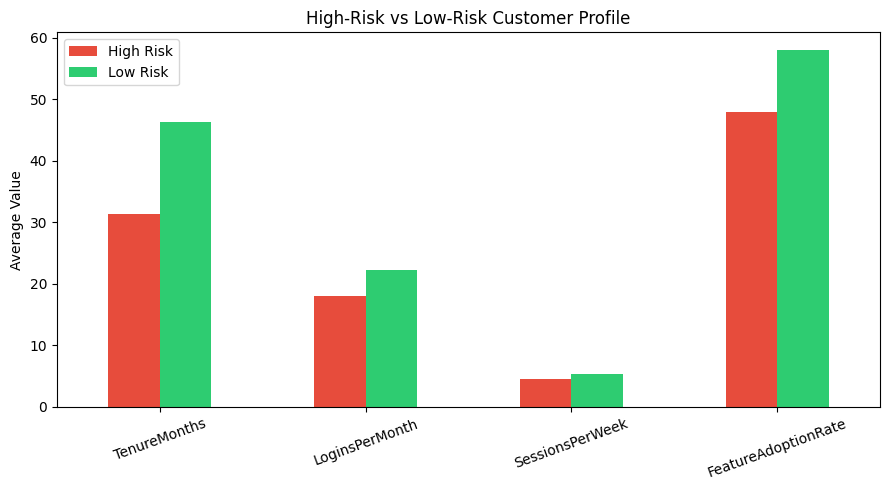

In [12]:
# Split customers into top 25% and bottom 25% by ChurnRiskScore.
q75 = df['ChurnRiskScore'].quantile(0.75)
q25 = df['ChurnRiskScore'].quantile(0.25)

high_risk = df[df['ChurnRiskScore'] >= q75]
low_risk = df[df['ChurnRiskScore'] <= q25]

profile_cols = ['TenureMonths', 'LoginsPerMonth', 'SessionsPerWeek', 'FeatureAdoptionRate']

print("High-risk group (top 25% ChurnRiskScore) averages:")
print(high_risk[profile_cols].mean())
print()
print("Low-risk group (bottom 25% ChurnRiskScore) averages:")
print(low_risk[profile_cols].mean())

# Visualize side by side
comparison = pd.DataFrame({
    'High Risk': high_risk[profile_cols].mean(),
    'Low Risk': low_risk[profile_cols].mean()
})
comparison.plot(kind='bar', figsize=(9, 5), color=['#e74c3c', '#2ecc71'])
plt.title('High-Risk vs Low-Risk Customer Profile')
plt.ylabel('Average Value')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Business Question 9: High-risk customer profile

**Finding:** Customers in the top 25% of ChurnRiskScore average 31.5 months
tenure, 18.1 logins/month, 4.6 sessions/week, and 48.0% feature adoption -
compared to 46.3 months, 22.2 logins/month, 5.3 sessions/week, and 58.0%
feature adoption for the bottom 25% (lowest risk).

**Interpretation:** All four characteristics diverge consistently and
meaningfully between high-risk and low-risk customers, confirming that
ChurnRiskScore's internal logic aligns with the tenure and engagement drivers
identified earlier (Q2, Q5). This gives us a concrete, recognizable profile:
the highest-risk customer is relatively new, logs in less often, and uses
fewer product features than their peers.

**Business implication:** Retention teams can use this profile (short tenure +
low login/session/feature-adoption activity) as a practical, actionable filter
for identifying at-risk customers proactively, rather than waiting for churn
to already occur.

/tmp/ipykernel_2289/4174607911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='ChurnRiskScore', palette=['#2ecc71', '#e74c3c'])


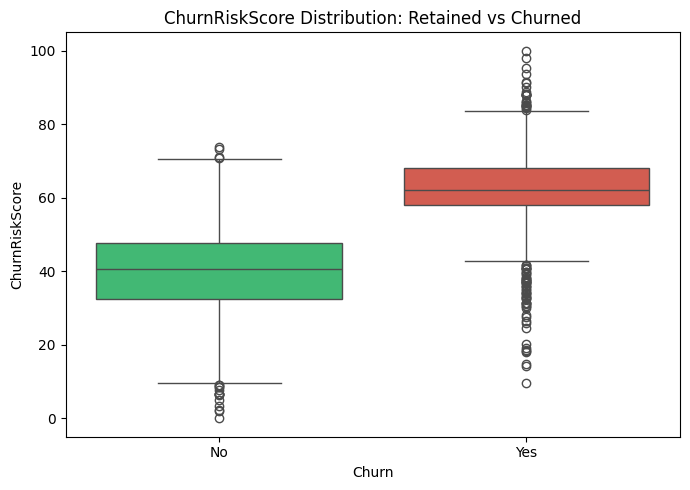

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Churn', y='ChurnRiskScore', palette=['#2ecc71', '#e74c3c'])
plt.title('ChurnRiskScore Distribution: Retained vs Churned')
plt.tight_layout()
plt.show()

## Business Question 10: Risk score alignment with observed churn

**Finding:** ChurnRiskScore distributions are clearly separated between
retained (median ~40.5) and churned (median ~62.0) customers, with some
overlap but a distinct shift.

**Interpretation:** ChurnRiskScore is a genuinely useful practical indicator
of churn risk - not perfect (some overlap exists, meaning it won't catch
every case or avoid every false positive), but reliable enough to support
targeting decisions. This confirms Objective 4 is achievable using the
existing score rather than needing to build a new risk model from scratch.

## Business Question 11: Priority segments for retention outreach

**Finding (synthesis):** Combining Q1 (contract risk), Q2 (tenure risk), Q8
(segment risk/value), and Q9 (behavioral profile):

1. **Corporate + short tenure + Month-to-Month**: Highest financial exposure
   (KES 48.9M CLV lost) combined with elevated churn risk factors.
2. **Government + short tenure + Month-to-Month**: Highest churn RATE (37.3%)
   of any segment, though lower per-customer value than Corporate.
3. **SME + short tenure + Month-to-Month**: Second-highest CLV lost (KES
   32.0M), representing substantial financial exposure worth proactive
   attention.

**Note:** Student segment was explicitly excluded from priority - despite
having "new/month-to-month" risk characteristics, it shows the lowest churn
rate (16.5%) and lowest CLV lost (KES 2.3M) of any segment, illustrating that
segment-level evidence should override general risk patterns when they conflict.

## Business Question 12: Interventions by driver

**Synthesis:** Rather than treating each driver in isolation, interventions
should combine into a risk-based program - customers exhibiting multiple risk
factors simultaneously (e.g. new + month-to-month + low engagement + recent
complaint) warrant more intensive intervention than any single factor alone.

Driver-specific interventions:
- **Contract Type:** Targeted upgrade offers (discount/data benefits) to move
  Month-to-Month customers onto 12/24-month contracts.
- **Tenure:** Structured 30/60/90-day onboarding program with proactive
  check-ins for customers in their first 6 months.
- **Support experience:** Auto-flag customers with multiple complaints/
  escalations for priority resolution and retention-agent follow-up within 48h.
- **Engagement:** Personalized re-engagement campaigns highlighting unused
  features, paired with short-term usage incentives, triggered by login/
  session decline.
- **Satisfaction:** Direct retention-agent outreach for low CSAT/NPS
  responses, with issue resolution and structured follow-up.